<a href="https://colab.research.google.com/github/hayaabokmail/Dissertation-code-files/blob/main/Saudi%20attrition%20prediction%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Data Loading and Exploration


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_excel('/content/drive/MyDrive/Dissertation/Original Dataset of Employee Attrition.xlsx')
df.head()

,ID,Attrition,Gender,Age,Maritalstatus,Academic_degree,Years_Experience,Years_experience_lastorganization,Sector,Department,...,Job_Engagement,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities
0,11,Yes,Female,31 to 40,Married,Master's,Less than 5 years,Less than 5 years,Medical sector,Accounting,...,Medium,Medium,Medium,Yes,No,No,Yes,Medium,Not satisfied,Yes
1,12,No,Female,21 to 30,Single,Master's,Less than 5 years,Less than 5 years,Medical sector,Accounting,...,Medium,Medium,Medium,No,No,Yes,No,Medium,Satisfied,No
2,13,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Close,Medium,Yes,Sometimes,No,No,Medium,Satisfied,Yes
3,14,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Medium,Medium,Yes,Yes,No,No,Low,Not satisfied,No
4,15,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Medium,Medium,Sometimes,Sometimes,No,No,Medium,Not satisfied,No


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1191
Columns: 35


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1191 entries, 0 to 1190
Data columns (total 35 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   ID                                          1191 non-null   int64 
 1   Attrition                                   1191 non-null   object
 2   Gender                                      1191 non-null   object
 3   Age                                         1191 non-null   object
 4    Maritalstatus                              1191 non-null   object
 5    Academic_degree                            1191 non-null   object
 6   Years_Experience                            1191 non-null   object
 7   Years_experience_lastorganization           1191 non-null   object
 8   Sector                                      1191 non-null   object
 9   Department                                  1191 non-null   object
 10  JobTitle                

The Saudi Employee Attrition dataset initially contained 1,191 employee records and 35 variables. After removing one duplicated record and the non-predictive ID variable, the final analytical sample contained 1,190 employees and 33 predictor variables.

In [5]:
df.describe()

,ID,Allowances
count,1191.000000,1191.000000
mean,612.910999,1.222502
std,346.732295,1.187483
min,11.000000,0.000000
25%,314.500000,0.000000
50%,613.000000,1.000000
75%,912.500000,2.000000
max,1213.000000,4.000000


In [6]:
# Clean column names
df.columns = (
    df.columns
      .str.replace("\u00a0", " ", regex=False)
      .str.strip()
)

# Clean all categorical values
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    df[col] = (
        df[col]
        .astype("string")
        .str.replace("\u00a0", " ", regex=False)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

print(df["Gender"].value_counts(dropna=False))
print(df["Gender"].unique())
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

Gender
Female    678
Male      513
Name: count, dtype: Int64
<StringArray>
['Female', 'Male']
Length: 2, dtype: string


##Attirition Variable Distrubution

In [7]:
df["Attrition"].value_counts(normalize=True)*100

,proportion
Attrition,
No,56.759026
Yes,43.240974


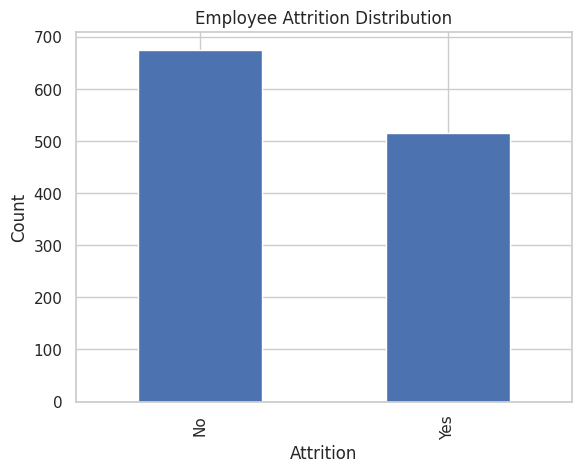

In [8]:
import matplotlib.pyplot as plt

df["Attrition"].value_counts().plot(kind="bar")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

## Gender Distribution

In [9]:
df.columns = df.columns.str.strip()
print(df["Gender"].value_counts(dropna=False))

Gender
Female    678
Male      513
Name: count, dtype: Int64


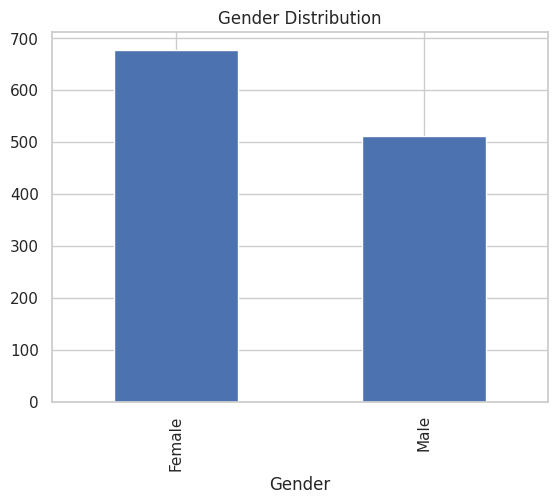

In [10]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.show()

## Age analysis

In [11]:
df["Age"].describe()

,Age
count,1191
unique,4
top,21 to 30
freq,592


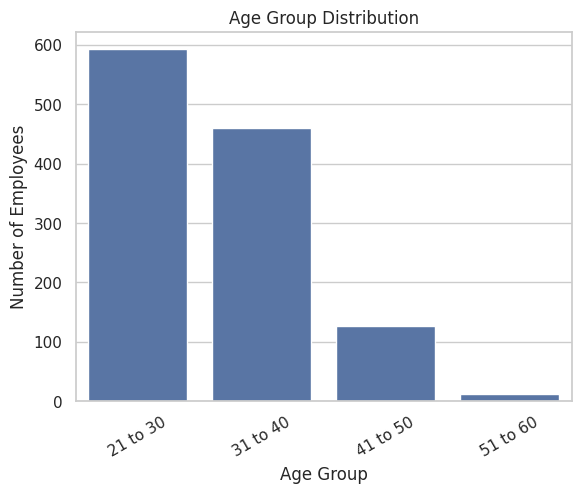

In [12]:
sns.countplot(
    data=df,
    x="Age",
    order=df["Age"].value_counts().index
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.xticks(rotation=30)
plt.show()

## Data imbalance analysis

In [13]:
attrition_rate = (
    df["Attrition"]
    .value_counts(normalize=True)*100
)

print(attrition_rate)

Attrition
No     56.759026
Yes    43.240974
Name: proportion, dtype: Float64


## Relationship between Gender and Attrition

In [14]:
pd.crosstab(
    df["Gender"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
Gender,,
Female,60.766962,39.233038
Male,51.461988,48.538012


## Relation between age and attrition

In [15]:
import numpy as np

# Function to convert age ranges to numeric midpoints
def convert_age_to_numeric(age_range):
    if isinstance(age_range, str):
        age_range = age_range.strip() # Remove any leading/trailing spaces
        if "to" in age_range:
            parts = age_range.split("to")
            try:
                lower = int(parts[0].strip())
                upper = int(parts[1].strip())
                return (lower + upper) / 2
            except ValueError:
                return np.nan # Return NaN if parts are not valid numbers
        elif "or more" in age_range:
            try:
                lower = int(age_range.split(" ")[0].strip())
                # For "51 or more", assuming the midpoint is 5 years above the lower bound
                return lower + 5
            except ValueError:
                return np.nan
    return np.nan # Return NaN for non-string values or unhandled formats

# Apply the conversion to create a numerical 'Numeric_Age' column
df['Numeric_Age'] = df['Age'].apply(convert_age_to_numeric)

# Calculate the mean of the new numerical 'Age' column grouped by 'Attrition'
print(df.groupby("Attrition")["Numeric_Age"].mean())

Attrition
No     32.186391
Yes    31.325243
Name: Numeric_Age, dtype: float64


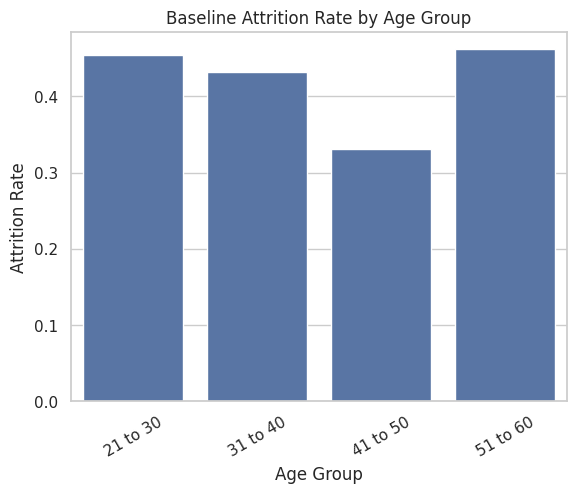

In [16]:
eda_df = df.copy()

eda_df["AttritionBinary"] = (
    eda_df["Attrition"]
    .str.strip()
    .map({"No": 0, "Yes": 1})
)

sns.barplot(
    data=eda_df,
    x="Age",
    y="AttritionBinary",
    order=df["Age"].value_counts().index,
    errorbar=None
)

plt.title("Baseline Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate")
plt.xticks(rotation=30)
plt.show()

In [17]:
df = pd.read_excel(
    "/content/drive/MyDrive/Dissertation/"
    "Original Dataset of Employee Attrition.xlsx"
)

# Clean column names
df.columns = (
    df.columns
    .str.replace("\u00a0", " ", regex=False)
    .str.strip()
)

# Clean categorical values
object_cols = df.select_dtypes(
    include=["object", "string"]
).columns

for col in object_cols:
    df[col] = (
        df[col]
        .astype("string")
        .str.replace("\u00a0", " ", regex=False)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Check duplicates while excluding the identifier
substantive_columns = [
    col for col in df.columns
    if col != "ID"
]

print(
    "Duplicate records excluding ID:",
    df.duplicated(
        subset=substantive_columns
    ).sum()
)

# Remove duplicate substantive records
df = df.drop_duplicates(
    subset=substantive_columns
).reset_index(drop=True)

# Remove the identifier
df = df.drop(columns=["ID"])

print("Final sample size:", len(df))

df["Attrition"] = df["Attrition"].str.strip().map({"No": 0, "Yes": 1})

Duplicate records excluding ID: 1
Final sample size: 1190


In [18]:

age_group_map = {
    "21 to 30": "Young",
    "31 to 40": "Young",
    "41 to 50": "Senior",
    "51 to 60": "Senior",
    "51 or more": "Senior"
}

df["AgeGroup"] = df["Age"].map(age_group_map)

2. Data Preprocessing


## remove non infromative variables

In [19]:
for col in ["Years_Experience",
            "Years_experience_lastorganization"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Years_Experience
Years_Experience
From 5 to 10 years     500
Less than 5 years      497
From 11 to 15 years    114
From 16 to 20 years     46
From 21 to 25 years     20
From 26 to 30 years      9
From 31 to 35 years      4
Name: count, dtype: Int64

Years_experience_lastorganization
Years_experience_lastorganization
Less than 5 years      715
From 5 to 10 years     352
From 11 to 15 years     75
From 16 to 20 years     26
From 21 to 25 years     13
From 26 to 30 years      5
From 31 to 35 years      4
Name: count, dtype: Int64


In [20]:

# Save protected attributes for fairness analysis
protected_df = df[["Gender", "AgeGroup"]].copy()

# Define predictors and target
X = df.drop(columns=["Attrition", "AgeGroup"])
y = df["Attrition"]

# Remove non-predictive identifiers if present
columns_to_drop = [
    col for col in ["ID", "Employee_ID", "Timestamp", "Email"]
    if col in X.columns
]

X = X.drop(columns=columns_to_drop)

# Identify feature types AFTER creating X
categorical_cols = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Categorical variables:", len(categorical_cols))
print(categorical_cols)

print("\nNumeric variables:", len(numeric_cols))
print(numeric_cols)

print("\nTotal predictors:", len(categorical_cols) + len(numeric_cols))

Categorical variables: 32
['Gender', 'Age', 'Maritalstatus', 'Academic_degree', 'Years_Experience', 'Years_experience_lastorganization', 'Sector', 'Department', 'JobTitle', 'MonthlySalary', 'MedicalInsurance', 'Bonus', 'OverTime', 'Payment_Overtime', 'Rewards&Wages_Satisfaction', 'Get_ Deserved_Promotion', 'Training_programs_ During_last_three_years', 'Useful_Training_Programs', 'Business_Travel', 'Job_Support', 'Recognition', 'Emotional_Commitment', 'Job_Engagement', 'Distance_to_work', 'Work_Live_Balance', 'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability', 'Health_Issues', 'Environment_Satisfaction', 'Job_Satisfaction', 'Job_Opportunities']

Numeric variables: 1
['Allowances']

Total predictors: 33


In [21]:
# split the data
from sklearn.model_selection import train_test_split

(
    X_train,
    X_test,
    y_train,
    y_test,
    protected_train,
    protected_test
) = train_test_split(
    X,
    y,
    protected_df,
    test_size=0.20,
    stratify=y,
    random_state=42
)

gender_test = protected_test["Gender"].reset_index(drop=True)
age_group_test = protected_test["AgeGroup"].reset_index(drop=True)

# Clean protected attributes by stripping whitespace from values
gender_test = gender_test.str.strip()
age_group_test = age_group_test.str.strip()

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTest gender distribution:")
print(gender_test.value_counts())
print("\nTest age-group distribution:")
print(age_group_test.value_counts())

Train shape: (952, 33)
Test shape: (238, 33)

Test gender distribution:
Gender
Female    142
Male       96
Name: count, dtype: Int64

Test age-group distribution:
AgeGroup
Young     214
Senior     24
Name: count, dtype: int64


In [22]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

3. Majority-Class Baseline


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_baseline = np.zeros(len(y_test))

print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_baseline))
print("F1:", f1_score(y_test, y_pred_baseline))

Accuracy: 0.5672268907563025
Precision: 0.0
Recall: 0.0
F1: 0.0


4. Models and Selected Imbalance Methods


In [24]:
!pip install imbalanced-learn

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTEENN, SMOTETomek

resamplers = {
    "Original": None,
    "ROS": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "RUS": RandomUnderSampler(random_state=42),
    "NearMiss": NearMiss(version=1),
    "SMOTE+ENN": SMOTEENN(random_state=42),
    "SMOTE+Tomek": SMOTETomek(random_state=42)
}

# Ratio required by XGBoost
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
xgb_scale_pos_weight = negative_count / positive_count

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )

}

5. Training-Only Cross-Validation


In [26]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline

# 5-fold stratified cross-validation on training data only
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv_results = []

for resampler_name, resampler in resamplers.items():

    print(f"\nEvaluating resampler: {resampler_name}")

    for model_name, model in models.items():

        print(f"  Model: {model_name}")

        steps = [
            ("preprocessor", clone(preprocessor))
        ]

        if resampler is not None:
            steps.append(("resampler", clone(resampler)))

        steps.append(("model", clone(model)))

        pipeline = Pipeline(steps=steps)

        scores = cross_validate(
            estimator=pipeline,
            X=X_train,
            y=y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False,
            error_score=np.nan # Changed from "raise" to np.nan to handle errors gracefully
        )

        cv_results.append({
            "Resampler": resampler_name,
            "Model": model_name,
            "CV_Precision_Mean": scores["test_precision"].mean(),
            "CV_Recall_Mean": scores["test_recall"].mean(),
            "CV_F1_Mean": scores["test_f1"].mean(),
            "CV_Balanced_Accuracy_Mean": scores["test_balanced_accuracy"].mean(),
            "CV_ROC_AUC_Mean": scores["test_roc_auc"].mean(),
            "CV_PR_AUC_Mean": scores["test_average_precision"].mean()
        })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by=["Model", "CV_F1_Mean", "CV_Recall_Mean"],
    ascending=[True, False, False]
)

display(cv_results_df)


Evaluating resampler: Original
  Model: Logistic Regression
  Model: Random Forest
  Model: Gradient Boosting
  Model: XGBoost
  Model: SVM

Evaluating resampler: ROS
  Model: Logistic Regression
  Model: Random Forest
  Model: Gradient Boosting
  Model: XGBoost
  Model: SVM

Evaluating resampler: SMOTE
  Model: Logistic Regression
  Model: Random Forest
  Model: Gradient Boosting
  Model: XGBoost
  Model: SVM

Evaluating resampler: RUS
  Model: Logistic Regression
  Model: Random Forest
  Model: Gradient Boosting
  Model: XGBoost
  Model: SVM

Evaluating resampler: NearMiss
  Model: Logistic Regression
  Model: Random Forest
  Model: Gradient Boosting
  Model: XGBoost
  Model: SVM

Evaluating resampler: SMOTE+ENN
  Model: Logistic Regression
  Model: Random Forest
  Model: Gradient Boosting
  Model: XGBoost
  Model: SVM

Evaluating resampler: SMOTE+Tomek
  Model: Logistic Regression
  Model: Random Forest
  Model: Gradient Boosting
  Model: XGBoost
  Model: SVM


,Resampler,Model,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_Balanced_Accuracy_Mean,CV_ROC_AUC_Mean,CV_PR_AUC_Mean
7,ROS,Gradient Boosting,0.785567,0.783603,0.782093,0.807780,0.902757,0.893430
12,SMOTE,Gradient Boosting,0.798258,0.771466,0.782092,0.809102,0.898154,0.890868
22,NearMiss,Gradient Boosting,0.789376,0.771437,0.779117,0.806310,0.896878,0.887761
17,RUS,Gradient Boosting,0.765970,0.795739,0.779013,0.803680,0.900721,0.891732
2,Original,Gradient Boosting,0.812760,0.747105,0.775953,0.805247,0.898555,0.891040
32,SMOTE+Tomek,Gradient Boosting,0.791188,0.754393,0.770143,0.799631,0.897555,0.890157
27,SMOTE+ENN,Gradient Boosting,0.633113,0.883250,0.737102,0.746620,0.839133,0.783880
5,ROS,Logistic Regression,0.762700,0.771408,0.765898,0.794241,0.885623,0.876496
15,RUS,Logistic Regression,0.751321,0.781134,0.764587,0.790813,0.885879,0.876468
10,SMOTE,Logistic Regression,0.766132,0.759242,0.761523,0.790936,0.884156,0.874622


In [27]:
#select best resampler
best_cv_configs = (
    cv_results_df
    .sort_values(
        by=["Model", "CV_F1_Mean", "CV_Recall_Mean"],
        ascending=[True, False, False]
    )
    .groupby("Model", as_index=False)
    .first()
)

display(best_cv_configs[
    [
        "Model",
        "Resampler",
        "CV_F1_Mean",
        "CV_Recall_Mean",
        "CV_Precision_Mean",
        "CV_Balanced_Accuracy_Mean",
        "CV_ROC_AUC_Mean",
        "CV_PR_AUC_Mean"
    ]
])

,Model,Resampler,CV_F1_Mean,CV_Recall_Mean,CV_Precision_Mean,CV_Balanced_Accuracy_Mean,CV_ROC_AUC_Mean,CV_PR_AUC_Mean
0,Gradient Boosting,ROS,0.782093,0.783603,0.785567,0.807780,0.902757,0.893430
1,Logistic Regression,ROS,0.765898,0.771408,0.762700,0.794241,0.885623,0.876496
2,Random Forest,RUS,0.781008,0.829827,0.742220,0.802282,0.888461,0.855496
3,SVM,RUS,0.782247,0.822568,0.748865,0.805066,0.884867,0.857363
4,XGBoost,RUS,0.800139,0.812753,0.790344,0.823264,0.906719,0.898579


6. Final Test Performance


In [28]:
from sklearn.base import clone
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

final_models = {}
final_predictions = {}
final_probabilities = {}
final_test_results = []

for _, row in best_cv_configs.iterrows():

    model_name = row["Model"]
    resampler_name = row["Resampler"]

    model = clone(models[model_name])
    resampler = resamplers[resampler_name]

    steps = [
        ("preprocessor", clone(preprocessor))
    ]

    if resampler is not None:
        steps.append(("resampler", clone(resampler)))

    steps.append(("model", model))

    final_pipeline = Pipeline(steps=steps)

    # Train on the full training set
    final_pipeline.fit(X_train, y_train)

    # Use the held-out test set once for final evaluation
    y_pred = final_pipeline.predict(X_test)
    y_prob = final_pipeline.predict_proba(X_test)[:, 1]

    final_models[model_name] = final_pipeline
    final_predictions[model_name] = y_pred
    final_probabilities[model_name] = y_prob

    final_test_results.append({
        "Model": model_name,
        "Selected_Resampler": resampler_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob)
    })

final_test_results_df = pd.DataFrame(final_test_results)

display(
    final_test_results_df.sort_values(
        by="F1",
        ascending=False
    )
)

,Model,Selected_Resampler,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Gradient Boosting,ROS,0.785714,0.780043,0.760000,0.737864,0.748768,0.866235,0.863899
3,SVM,RUS,0.781513,0.776339,0.752475,0.737864,0.745098,0.851277,0.829904
4,XGBoost,RUS,0.781513,0.775189,0.757576,0.728155,0.742574,0.868896,0.863138
1,Logistic Regression,ROS,0.760504,0.755520,0.725490,0.718447,0.721951,0.866523,0.863850
2,Random Forest,RUS,0.743697,0.740705,0.698113,0.718447,0.708134,0.832183,0.808884


7. Class-Weight Baseline Comparison


In [29]:
from sklearn.base import clone
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Ratio required by XGBoost
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
xgb_scale_pos_weight = negative_count / positive_count

print("XGBoost scale_pos_weight:", xgb_scale_pos_weight)

# Class-weighted versions of the five classifiers
class_weighted_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=xgb_scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}

XGBoost scale_pos_weight: 1.316301703163017


In [30]:
class_weight_models = {}
class_weight_predictions = {}
class_weight_probabilities = {}
class_weight_results = []

# Balanced observation weights for Gradient Boosting
gb_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

for model_name, model in class_weighted_models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", clone(model))
    ])

    # Gradient Boosting uses sample weights
    if model_name == "Gradient Boosting":
        pipeline.fit(
            X_train,
            y_train,
            model__sample_weight=gb_sample_weights
        )
    else:
        pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    class_weight_models[model_name] = pipeline
    class_weight_predictions[model_name] = y_pred
    class_weight_probabilities[model_name] = y_prob

    class_weight_results.append({
        "Model": model_name,
        "Condition": "Class Weight",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob)
    })

class_weight_results_df = pd.DataFrame(class_weight_results)

display(
    class_weight_results_df.sort_values(
        by="F1",
        ascending=False
    )
)

,Model,Condition,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,Gradient Boosting,Class Weight,0.785714,0.781194,0.754902,0.747573,0.751220,0.866523,0.862447
3,XGBoost,Class Weight,0.789916,0.781446,0.778947,0.718447,0.747475,0.873283,0.869932
0,Logistic Regression,Class Weight,0.773109,0.767781,0.742574,0.728155,0.735294,0.867170,0.864547
4,SVM,Class Weight,0.764706,0.760374,0.728155,0.728155,0.728155,0.853003,0.833905
1,Random Forest,Class Weight,0.768908,0.757174,0.766667,0.669903,0.715026,0.841855,0.820572


In [31]:
selected_resampling_results = final_test_results_df.copy()

selected_resampling_results["Condition"] = (
    "Selected Resampling: "
    + selected_resampling_results["Selected_Resampler"].astype(str)
)

comparison_columns = [
    "Model",
    "Condition",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

imbalance_strategy_comparison_df = pd.concat(
    [
        selected_resampling_results[comparison_columns],
        class_weight_results_df[comparison_columns]
    ],
    ignore_index=True
)

imbalance_strategy_comparison_df = (
    imbalance_strategy_comparison_df
    .sort_values(
        by=["Model", "F1"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(imbalance_strategy_comparison_df)

,Model,Condition,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Gradient Boosting,Class Weight,0.785714,0.781194,0.754902,0.747573,0.751220,0.866523,0.862447
1,Gradient Boosting,Selected Resampling: ROS,0.785714,0.780043,0.760000,0.737864,0.748768,0.866235,0.863899
2,Logistic Regression,Class Weight,0.773109,0.767781,0.742574,0.728155,0.735294,0.867170,0.864547
3,Logistic Regression,Selected Resampling: ROS,0.760504,0.755520,0.725490,0.718447,0.721951,0.866523,0.863850
4,Random Forest,Class Weight,0.768908,0.757174,0.766667,0.669903,0.715026,0.841855,0.820572
5,Random Forest,Selected Resampling: RUS,0.743697,0.740705,0.698113,0.718447,0.708134,0.832183,0.808884
6,SVM,Selected Resampling: RUS,0.781513,0.776339,0.752475,0.737864,0.745098,0.851277,0.829904
7,SVM,Class Weight,0.764706,0.760374,0.728155,0.728155,0.728155,0.853003,0.833905
8,XGBoost,Class Weight,0.789916,0.781446,0.778947,0.718447,0.747475,0.873283,0.869932
9,XGBoost,Selected Resampling: RUS,0.781513,0.775189,0.757576,0.728155,0.742574,0.868896,0.863138


8. Gender and Age Fairness


In [32]:
import numpy as np


def fairness_metrics_fixed(
    y_true,
    y_pred,
    sensitive_feature,
    group1,
    group2
):

    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    sensitive_feature = np.asarray(sensitive_feature)

    group_metrics = {}

    for group in [group1, group2]:
        mask = sensitive_feature == group

        if mask.sum() == 0:
            raise ValueError(f"No observations found for group: {group}")

        y_true_group = y_true[mask]
        y_pred_group = y_pred[mask]

        actual_positives = np.sum(y_true_group == 1)
        predicted_positives = np.sum(y_pred_group == 1)

        true_positives = np.sum(
            (y_true_group == 1) & (y_pred_group == 1)
        )

        # Recall is undefined if the group has no true positive cases
        tpr = (
            true_positives / actual_positives
            if actual_positives > 0
            else np.nan
        )

        # Positive prediction rate
        selection_rate = np.mean(y_pred_group == 1)

        # Precision is undefined if the model predicts no positives
        precision = (
            true_positives / predicted_positives
            if predicted_positives > 0
            else np.nan
        )

        group_metrics[group] = {
            "TPR": tpr,
            "Selection_Rate": selection_rate,
            "Precision": precision
        }

    return {
        "Group1": group1,
        "Group2": group2,

        "EOD": (
            group_metrics[group1]["TPR"]
            - group_metrics[group2]["TPR"]
        ),

        "DPD": (
            group_metrics[group1]["Selection_Rate"]
            - group_metrics[group2]["Selection_Rate"]
        ),

        "Predictive_Parity": (
            group_metrics[group1]["Precision"]
            - group_metrics[group2]["Precision"]
        )
    }

In [33]:
# gender fairness
# Gender fairness for the final CV-selected models

gender_results = {}

for model_name, preds in final_predictions.items():

    gender_results[model_name] = fairness_metrics_fixed(
        y_test,
        preds,
        gender_test,
        group1="Female",
        group2="Male"
    )

gender_df = pd.DataFrame(gender_results).T

display(gender_df)

,Group1,Group2,EOD,DPD,Predictive_Parity
Gradient Boosting,Female,Male,-0.14966,-0.151262,-0.110444
Logistic Regression,Female,Male,-0.108844,-0.137177,-0.096265
Random Forest,Female,Male,-0.186697,-0.178844,-0.113208
SVM,Female,Male,-0.227513,-0.214055,-0.084119
XGBoost,Female,Male,-0.207105,-0.193222,-0.095588


In [34]:
# Gender fairness - Class Weighted Models

gender_results_class_weight = {}

for model_name, preds in class_weight_predictions.items():

    gender_results_class_weight[model_name] = fairness_metrics_fixed(
        y_test,
        preds,
        gender_test,
        group1="Female",
        group2="Male"
    )

gender_class_weight_df = pd.DataFrame(
    gender_results_class_weight
).T

display(gender_class_weight_df)

,Group1,Group2,EOD,DPD,Predictive_Parity
Logistic Regression,Female,Male,-0.129252,-0.161678,-0.074118
Random Forest,Female,Male,-0.123583,-0.13439,-0.100791
Gradient Boosting,Female,Male,-0.053288,-0.0848,-0.129658
XGBoost,Female,Male,-0.225624,-0.169014,-0.152039
SVM,Female,Male,-0.246032,-0.21743,-0.104308


In [35]:
# Age fairness - Class Weighted Models

age_results_class_weight = {}

# Create age groups for the held-out test set
# Convert X_test["Age"] to numeric values before comparison

age_group_test = protected_test["AgeGroup"].reset_index(drop=True)

for model_name, preds in class_weight_predictions.items():

    age_results_class_weight[model_name] = fairness_metrics_fixed(
        y_test,
        preds,
        age_group_test,
        group1="Young",
        group2="Senior"
    )

age_class_weight_df = pd.DataFrame(
    age_results_class_weight
).T

display(age_class_weight_df)

,Group1,Group2,EOD,DPD,Predictive_Parity
Logistic Regression,Young,Senior,0.408103,0.286604,-0.268041
Random Forest,Young,Senior,0.241107,0.096184,0.056799
Gradient Boosting,Young,Senior,0.328063,0.152259,0.043609
XGBoost,Young,Senior,0.295455,0.165888,-0.058052
SVM,Young,Senior,0.306324,0.156931,0.014881


In [36]:
# age fairness
# Create age groups for the held-out test set

# Convert X_test["Age"] to numeric values before comparison

age_group_test = protected_test["AgeGroup"].reset_index(drop=True)

# Age fairness for the final CV-selected models

age_results = {}

for model_name, preds in final_predictions.items():

    age_results[model_name] = fairness_metrics_fixed(
    y_test,
    preds,
    age_group_test,
    group1="Young",
    group2="Senior"
)

age_df = pd.DataFrame(age_results).T

display(age_df)

,Group1,Group2,EOD,DPD,Predictive_Parity
Gradient Boosting,Young,Senior,0.215415,0.142913,-0.104455
Logistic Regression,Young,Senior,0.397233,0.291277,-0.285714
Random Forest,Young,Senior,0.193676,0.124611,-0.056122
SVM,Young,Senior,0.215415,0.101246,0.002688
XGBoost,Young,Senior,0.102767,0.0919,-0.127747


9. Bootstrap Confidence Intervals


In [37]:
import pandas as pd
import numpy as np


def bootstrap_fairness_fixed(
    y_true,
    y_pred,
    sensitive_feature,
    group1,
    group2,
    n_bootstrap=1000,
    random_state=42,
    verbose=False
    ):

    data = pd.DataFrame({
        "y_true": np.asarray(y_true, dtype=int),
        "y_pred": np.asarray(y_pred, dtype=int),
        "group": np.asarray(sensitive_feature)
    })

    # Retain only the two groups being compared
    data = data[
        data["group"].isin([group1, group2])
    ].reset_index(drop=True)

    # Show the original joint distribution
    stratum_counts = pd.crosstab(
        data["group"],
        data["y_true"]
    )

    if verbose:
        print(f"\nStratum counts for {group1} vs {group2}:")
        display(stratum_counts)

    # EOD requires at least one actual attrition case in each group
    for group in [group1, group2]:
        positive_count = (
            (data["group"] == group)
            & (data["y_true"] == 1)
        ).sum()

        if positive_count == 0:
            raise ValueError(
                f"EOD cannot be calculated because {group} "
                "contains no true attrition cases."
            )

    # Original test-set point estimate
    point_estimate = fairness_metrics_fixed(
        data["y_true"],
        data["y_pred"],
        data["group"],
        group1,
        group2
    )

    rng = np.random.default_rng(random_state)

    bootstrap_values = {
        "EOD": [],
        "DPD": [],
        "Predictive_Parity": []
    }

    # Create fixed group × outcome strata
    strata = [
        stratum.reset_index(drop=True)
        for _, stratum in data.groupby(
            ["group", "y_true"],
            observed=True
        )
    ]

    for _ in range(n_bootstrap):
        sampled_strata = []

        for stratum in strata:
            sampled_indices = rng.integers(
                low=0,
                high=len(stratum),
                size=len(stratum)
            )

            sampled_strata.append(
                stratum.iloc[sampled_indices]
            )

        bootstrap_sample = pd.concat(
            sampled_strata,
            ignore_index=True
        )

        # Shuffle rows after combining strata
        bootstrap_sample = bootstrap_sample.iloc[
            rng.permutation(len(bootstrap_sample))
        ].reset_index(drop=True)

        metrics = fairness_metrics_fixed(
            bootstrap_sample["y_true"],
            bootstrap_sample["y_pred"],
            bootstrap_sample["group"],
            group1,
            group2
        )

        for metric in bootstrap_values:
            value = metrics[metric]

            # Skip only an undefined metric, not the entire sample
            if np.isfinite(value):
                bootstrap_values[metric].append(value)

    results = {}

    for metric, values in bootstrap_values.items():
        values = np.asarray(values, dtype=float)

        if len(values) == 0:
            results[f"{metric} Estimate"] = point_estimate[metric]
            results[f"{metric} Lower"] = np.nan
            results[f"{metric} Upper"] = np.nan
            results[f"{metric} Valid Bootstraps"] = 0
            continue

        results[f"{metric} Estimate"] = point_estimate[metric]
        results[f"{metric} Lower"] = np.percentile(values, 2.5)
        results[f"{metric} Upper"] = np.percentile(values, 97.5)
        results[f"{metric} Valid Bootstraps"] = len(values)

    return results

In [38]:
age_bootstrap_check = pd.crosstab(
    age_group_test,
    y_test,
    rownames=["Age Group"],
    colnames=["Attrition"]
)

display(age_bootstrap_check)

Attrition,0,1
Age Group,,
Senior,13,11
Young,122,92


In [39]:
gender_bootstrap_results = {}

for model_name, preds in final_predictions.items():
    gender_bootstrap_results[model_name] = bootstrap_fairness_fixed(
        y_test,
        preds,
        gender_test,
        group1="Female",
        group2="Male"
    )

gender_bootstrap_df = pd.DataFrame(gender_bootstrap_results).T
display(gender_bootstrap_df)

,EOD Estimate,EOD Lower,EOD Upper,EOD Valid Bootstraps,DPD Estimate,DPD Lower,DPD Upper,DPD Valid Bootstraps,Predictive_Parity Estimate,Predictive_Parity Lower,Predictive_Parity Upper,Predictive_Parity Valid Bootstraps
Gradient Boosting,-0.149660,-0.305367,0.006047,1000.0,-0.151262,-0.252711,-0.046794,1000.0,-0.110444,-0.242438,0.030031,1000.0
Logistic Regression,-0.108844,-0.275605,0.054554,1000.0,-0.137177,-0.245026,-0.025961,1000.0,-0.096265,-0.229913,0.044163,1000.0
Random Forest,-0.186697,-0.338624,-0.025321,1000.0,-0.178844,-0.290053,-0.063597,1000.0,-0.113208,-0.252034,0.018895,1000.0
SVM,-0.227513,-0.379488,-0.073696,1000.0,-0.214055,-0.319473,-0.109001,1000.0,-0.084119,-0.223661,0.044729,1000.0
XGBoost,-0.207105,-0.360922,-0.047619,1000.0,-0.193222,-0.291296,-0.091766,1000.0,-0.095588,-0.229178,0.045943,1000.0


In [40]:
gender_bootstrap_class_weight = {}

for model_name, preds in class_weight_predictions.items():

    gender_bootstrap_class_weight[model_name] = bootstrap_fairness_fixed(
        y_test,
        preds,
        gender_test,
        group1="Female",
        group2="Male"
    )

gender_bootstrap_class_weight_df = pd.DataFrame(
    gender_bootstrap_class_weight
).T

display(gender_bootstrap_class_weight_df)

,EOD Estimate,EOD Lower,EOD Upper,EOD Valid Bootstraps,DPD Estimate,DPD Lower,DPD Upper,DPD Valid Bootstraps,Predictive_Parity Estimate,Predictive_Parity Lower,Predictive_Parity Upper,Predictive_Parity Valid Bootstraps
Logistic Regression,-0.129252,-0.286943,0.024707,1000.0,-0.161678,-0.266432,-0.056554,1000.0,-0.074118,-0.200707,0.067408,1000.0
Random Forest,-0.123583,-0.283390,0.052579,1000.0,-0.134390,-0.239499,-0.029343,1000.0,-0.100791,-0.239751,0.048688,1000.0
Gradient Boosting,-0.053288,-0.216733,0.104308,1000.0,-0.084800,-0.192635,0.016293,1000.0,-0.129658,-0.257909,0.000069,1000.0
XGBoost,-0.225624,-0.377646,-0.069917,1000.0,-0.169014,-0.263065,-0.067635,1000.0,-0.152039,-0.283058,-0.019065,1000.0
SVM,-0.246032,-0.396117,-0.086451,1000.0,-0.217430,-0.321897,-0.104977,1000.0,-0.104308,-0.238252,0.028157,1000.0


In [41]:
age_bootstrap_class_weight = {}

for model_name, preds in class_weight_predictions.items():

    age_bootstrap_class_weight[model_name] = (
        bootstrap_fairness_fixed(
            y_true=y_test,
            y_pred=preds,
            sensitive_feature=age_group_test,
            group1="Young",
            group2="Senior",
            n_bootstrap=1000,
            random_state=42
        )
    )

age_bootstrap_class_weight_df = pd.DataFrame(
    age_bootstrap_class_weight
).T

display(age_bootstrap_class_weight_df)

,EOD Estimate,EOD Lower,EOD Upper,EOD Valid Bootstraps,DPD Estimate,DPD Lower,DPD Upper,DPD Valid Bootstraps,Predictive_Parity Estimate,Predictive_Parity Lower,Predictive_Parity Upper,Predictive_Parity Valid Bootstraps
Logistic Regression,0.408103,0.102668,0.666107,1000.0,0.286604,0.147586,0.411994,1000.0,-0.268041,-0.340000,-0.186759,997.0
Random Forest,0.241107,-0.053458,0.524876,1000.0,0.096184,-0.084502,0.253894,1000.0,0.056799,-0.250075,0.374772,1000.0
Gradient Boosting,0.328063,0.026581,0.622530,1000.0,0.152259,-0.019470,0.314262,1000.0,0.043609,-0.271739,0.362481,1000.0
XGBoost,0.295455,-0.009881,0.589921,1000.0,0.165888,0.003407,0.318935,1000.0,-0.058052,-0.275537,0.255842,1000.0
SVM,0.306324,-0.009881,0.579595,1000.0,0.156931,-0.024241,0.328271,1000.0,0.014881,-0.280908,0.308845,1000.0


In [42]:

age_bootstrap_results = {}

for model_name, preds in final_predictions.items():

    print(f"\nModel: {model_name}")

    age_bootstrap_results[model_name] = (
        bootstrap_fairness_fixed(
            y_true=y_test,
            y_pred=preds,
            sensitive_feature=age_group_test,
            group1="Young",
            group2="Senior",
            n_bootstrap=1000,
            random_state=42
        )
    )

age_bootstrap_df = pd.DataFrame(
    age_bootstrap_results
).T

display(age_bootstrap_df)


Model: Gradient Boosting

Model: Logistic Regression

Model: Random Forest

Model: SVM

Model: XGBoost


,EOD Estimate,EOD Lower,EOD Upper,EOD Valid Bootstraps,DPD Estimate,DPD Lower,DPD Upper,DPD Valid Bootstraps,Predictive_Parity Estimate,Predictive_Parity Lower,Predictive_Parity Upper,Predictive_Parity Valid Bootstraps
Gradient Boosting,0.215415,-0.089921,0.499012,1000.0,0.142913,-0.014798,0.291277,1000.0,-0.104455,-0.294755,0.176625,1000.0
Logistic Regression,0.397233,0.091897,0.659091,1000.0,0.291277,0.152638,0.412101,1000.0,-0.285714,-0.356436,-0.208791,997.0
Random Forest,0.193676,-0.096937,0.499012,1000.0,0.124611,-0.042066,0.291277,1000.0,-0.056122,-0.329790,0.205340,1000.0
SVM,0.215415,-0.079051,0.520751,1000.0,0.101246,-0.065430,0.259063,1000.0,0.002688,-0.268041,0.266711,1000.0
XGBoost,0.102767,-0.180830,0.408103,1000.0,0.091900,-0.065820,0.244558,1000.0,-0.127747,-0.301133,0.109959,1000.0


10. Feature Importance


In [43]:
rf_pipeline = final_models["Random Forest"]
xgb_pipeline = final_models["XGBoost"]

rf_estimator = rf_pipeline.named_steps["model"]
xgb_estimator = xgb_pipeline.named_steps["model"]

rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
xgb_preprocessor = xgb_pipeline.named_steps["preprocessor"]

rf_feature_names = rf_preprocessor.get_feature_names_out()
xgb_feature_names = xgb_preprocessor.get_feature_names_out()

rf_importance = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_estimator.feature_importances_
}).sort_values("Importance", ascending=False)

xgb_importance = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_estimator.feature_importances_
}).sort_values("Importance", ascending=False)

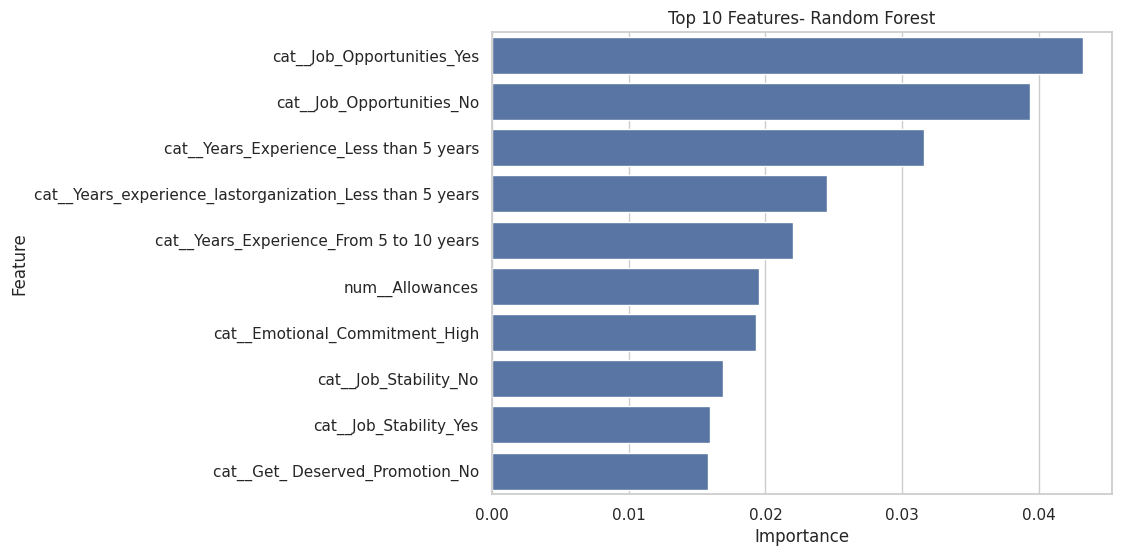

In [44]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Features- Random Forest')
plt.show()

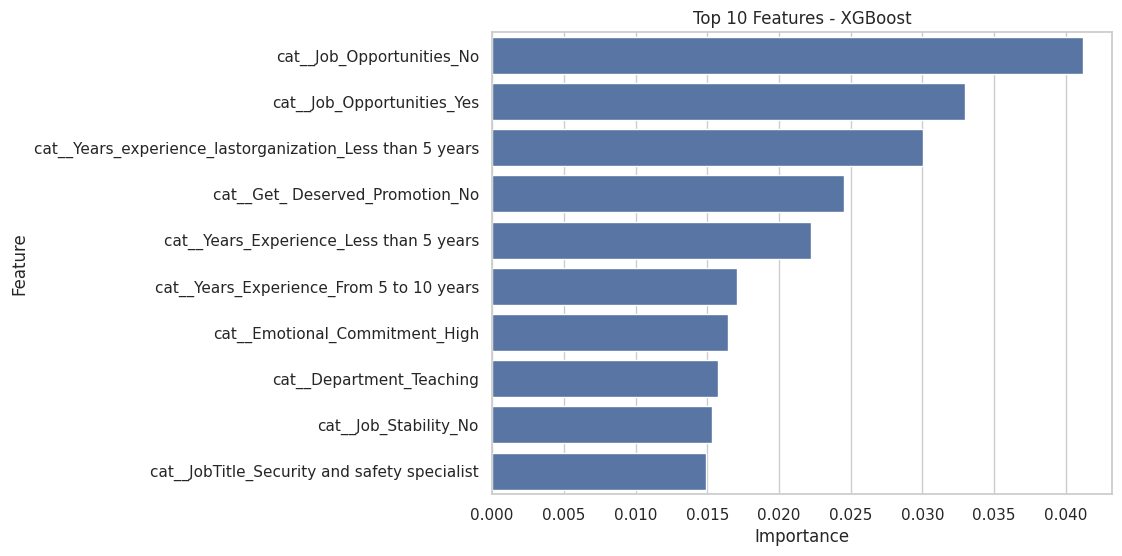

In [45]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=xgb_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Features - XGBoost')
plt.show()

11. Performance–Fairness Trade-off


In [46]:
# Create performance–fairness trade-off table
# using the final test results and final age fairness results

tradeoff_df = final_test_results_df[
    ["Model", "Selected_Resampler", "F1"]
].copy()

# Ensure that Age EOD is numeric
age_eod_map = pd.to_numeric(
    age_df["EOD"],
    errors="coerce"
).to_dict()

tradeoff_df["Age_EOD"] = tradeoff_df["Model"].map(age_eod_map)

# Smaller absolute EOD means closer to parity
tradeoff_df["Absolute_Age_EOD"] = tradeoff_df["Age_EOD"].abs()

# Absolute Age EOD
tradeoff_df = tradeoff_df.sort_values(
    by="Absolute_Age_EOD",
    ascending=True
).reset_index(drop=True)

#Absolute Gender EOD
gender_eod_map = pd.to_numeric(
    gender_df["EOD"],
    errors="coerce"
).to_dict()

#Gender DPD
gender_dpd_map = pd.to_numeric(
    gender_df["DPD"],
    errors="coerce"
).to_dict()
# F1 Score
tradeoff_df = tradeoff_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

tradeoff_df["Gender_EOD"] = (
    tradeoff_df["Model"].map(gender_eod_map)
)

tradeoff_df["Absolute_Gender_EOD"] = (
    tradeoff_df["Gender_EOD"].abs()
)

tradeoff_df["Gender_DPD"] = (
    tradeoff_df["Model"].map(gender_dpd_map)
)

tradeoff_df["Absolute_Gender_DPD"] = (
    tradeoff_df["Gender_DPD"].abs()
)

display(tradeoff_df)


,Model,Selected_Resampler,F1,Age_EOD,Absolute_Age_EOD,Gender_EOD,Absolute_Gender_EOD,Gender_DPD,Absolute_Gender_DPD
0,Gradient Boosting,ROS,0.748768,0.215415,0.215415,-0.149660,0.149660,-0.151262,0.151262
1,SVM,RUS,0.745098,0.215415,0.215415,-0.227513,0.227513,-0.214055,0.214055
2,XGBoost,RUS,0.742574,0.102767,0.102767,-0.207105,0.207105,-0.193222,0.193222
3,Logistic Regression,ROS,0.721951,0.397233,0.397233,-0.108844,0.108844,-0.137177,0.137177
4,Random Forest,RUS,0.708134,0.193676,0.193676,-0.186697,0.186697,-0.178844,0.178844


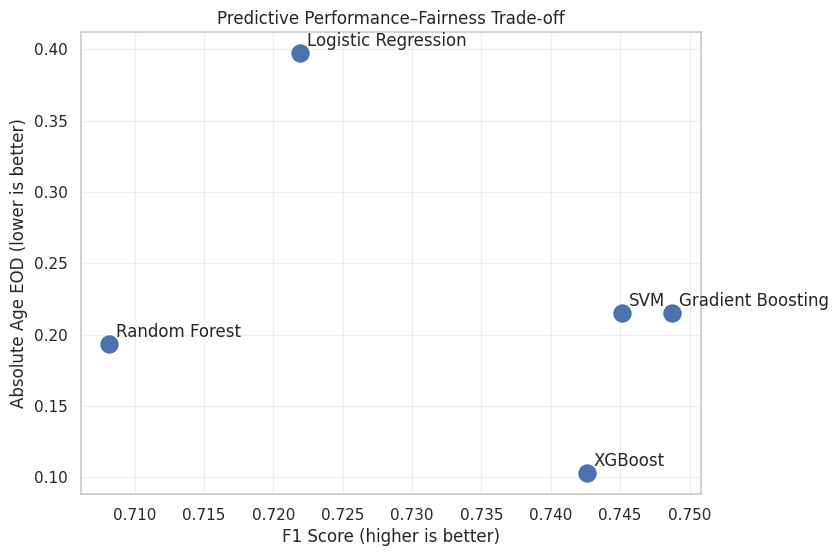

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    tradeoff_df["F1"],
    tradeoff_df["Absolute_Age_EOD"],
    s=150
)

for _, row in tradeoff_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["F1"], row["Absolute_Age_EOD"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("F1 Score (higher is better)")
plt.ylabel("Absolute Age EOD (lower is better)")
plt.title("Predictive Performance–Fairness Trade-off")
plt.grid(alpha=0.3)
plt.show()

In [48]:
gender_bootstrap_df

,EOD Estimate,EOD Lower,EOD Upper,EOD Valid Bootstraps,DPD Estimate,DPD Lower,DPD Upper,DPD Valid Bootstraps,Predictive_Parity Estimate,Predictive_Parity Lower,Predictive_Parity Upper,Predictive_Parity Valid Bootstraps
Gradient Boosting,-0.149660,-0.305367,0.006047,1000.0,-0.151262,-0.252711,-0.046794,1000.0,-0.110444,-0.242438,0.030031,1000.0
Logistic Regression,-0.108844,-0.275605,0.054554,1000.0,-0.137177,-0.245026,-0.025961,1000.0,-0.096265,-0.229913,0.044163,1000.0
Random Forest,-0.186697,-0.338624,-0.025321,1000.0,-0.178844,-0.290053,-0.063597,1000.0,-0.113208,-0.252034,0.018895,1000.0
SVM,-0.227513,-0.379488,-0.073696,1000.0,-0.214055,-0.319473,-0.109001,1000.0,-0.084119,-0.223661,0.044729,1000.0
XGBoost,-0.207105,-0.360922,-0.047619,1000.0,-0.193222,-0.291296,-0.091766,1000.0,-0.095588,-0.229178,0.045943,1000.0


In [49]:
age_bootstrap_df

,EOD Estimate,EOD Lower,EOD Upper,EOD Valid Bootstraps,DPD Estimate,DPD Lower,DPD Upper,DPD Valid Bootstraps,Predictive_Parity Estimate,Predictive_Parity Lower,Predictive_Parity Upper,Predictive_Parity Valid Bootstraps
Gradient Boosting,0.215415,-0.089921,0.499012,1000.0,0.142913,-0.014798,0.291277,1000.0,-0.104455,-0.294755,0.176625,1000.0
Logistic Regression,0.397233,0.091897,0.659091,1000.0,0.291277,0.152638,0.412101,1000.0,-0.285714,-0.356436,-0.208791,997.0
Random Forest,0.193676,-0.096937,0.499012,1000.0,0.124611,-0.042066,0.291277,1000.0,-0.056122,-0.329790,0.205340,1000.0
SVM,0.215415,-0.079051,0.520751,1000.0,0.101246,-0.065430,0.259063,1000.0,0.002688,-0.268041,0.266711,1000.0
XGBoost,0.102767,-0.180830,0.408103,1000.0,0.091900,-0.065820,0.244558,1000.0,-0.127747,-0.301133,0.109959,1000.0
